**Tabla de contenido**

- [Lectura de datos](#Lectura-de-datos)
- [Análisis exploratorio](#Analisis-exploratorio)
- [Preporcesamiento](#Preprocesamiento)
- [Modelado](#Modelado)

En este cuaderno realizaremos las predicciones de las ventas semanales usando una red neuronal. Para esta solución seguiremos los siguientes pasos:

- `Lectura de datos`
- `Análisis exploratorio`: valores nan, valores dúplicados, estudio de valores atípicos, ingenieria de características, correlaciones.
- `Preparación de los datos`
- `Modelado`
- `Evaluación`

# Lectura de datos

In [1]:
import pandas as pd
import numpy as np
import os

file_path = lambda file: os.path.join(os.getcwd(),'data',file)
df = pd.read_csv(file_path('WalmartSalesClean.csv'))
df.head(3)

,Date,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Events
0,2010-02-12,1,164195744,1,38.51,2.548,211.242176,8.106,1
1,2010-02-19,1,161196816,0,39.93,2.514,211.289139,8.106,0
2,2010-02-26,1,140972752,0,46.63,2.561,211.319642,8.106,0


# Analisis exploratorio

Recoredemos que el análisis exploratiorio se realiza para conocer el dataset y las variables que tenemos. Así mismo, se estudian cada una de las variables con el propósito de dar respuestas a las preguntas de inmvestigación. En este caso son las siguientes:

- Pueden estos datos utilizarsen para predecir las ventas semanales de cada una de las tiendas?
- Hay correlaciones fuertes con la variable objetivo (ventas)

Pero antes de responder a estas preguntas, veamos como están los datos.

In [2]:
# valores nan
val_nan = {col:df[col].isnull().sum() for col in df.columns}
val_nan = pd.DataFrame.from_dict(val_nan, orient='index',columns=['nulos'])
val_nan.head()

,nulos
Date,0
Store,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0


Podemos ver que el dataframe no contiene valores faltantes. Ahora veamos si hay valores repetidos

In [3]:
duplicados = df[df.duplicated(keep=False)] # incluye la primera aparición
duplicados.head()

,Date,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Events


Podemos ver que no tenemos registros dúplicados, esto es bueno. Ahora convirtamos la fecha a formato Datetime.

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

Ahora si, veamos los valores atípicos, este caso usaremos boxplots para una mejor interpretación.

In [5]:
import plotly.graph_objects as go
import plotly.colors as pc
import plotly.express as px


def plot_boxplots(df, title='Boxplots por variable', height=300):
    """
    Genera un boxplot interactivo con colores variados para cada columna numérica del DataFrame.

    Parámetros:
    - df: pandas.DataFrame con los datos
    - title: título del gráfico
    - height: altura del gráfico en píxeles
    """
    fig = go.Figure()

    numeric_cols = df.select_dtypes(include='number').columns
    colors = pc.qualitative.Plotly  # paleta de colores categóricos

    for i, column in enumerate(numeric_cols):
        fig.add_trace(go.Box(
            y=df[column],
            name=column,
            boxpoints='outliers',
            marker=dict(size=4, color=colors[i % len(colors)]),
            line=dict(color=colors[i % len(colors)]),
            fillcolor=colors[i % len(colors)],
        ))

    fig.update_layout(
        title=title,
        yaxis_title='Valor',
        boxmode='group',
        template='plotly_white',
        font=dict(family='Arial', size=14),
        margin=dict(l=40, r=40, t=60, b=40),
        height=height,
        showlegend=False,
    )

    fig.show()


plot_boxplots(df = df[df.columns.difference(['Date','Weekly_Sales'])], title='Distribución de las variables', height=300)

Podemos observar lo siguiente:
- las características predictoras están en rangos diferentes.
- CPI: Los datos están muy dispersos con respecto a la media, es decir, los datos no se concentran al rededor de la media.
- La temperatura no está en en grados celcius pues la media oscila alrededor de 62.

Hay muy pocos valores atípicos y la matoria están en la variable `Unemployment`, veamos ahora las distribuciones de los datos.

In [6]:
import plotly.subplots as sp
import plotly.graph_objects as go

def plot_histograms_grid(df, exclude_cols=['Date'], bins=None, title="Distribuciones"):
    """
    Genera un grid de histogramas para cada columna numérica del DataFrame,
    excluyendo las columnas especificadas en `exclude_cols`.

    Parámetros:
        df (pd.DataFrame): DataFrame de entrada.
        exclude_cols (list): Columnas a excluir (por defecto ['Date']).
        bins (int): Número de bins para los histogramas. Si es None, se calcula automáticamente.
        title (str): Título general de la figura.
    
    Retorna:
        fig (go.Figure): Figura con los subplots.
    """
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns        # Filtrar columnas numéricas y excluir las no deseadas
    cols_to_plot = numeric_cols.difference(exclude_cols)
    n = len(cols_to_plot)
    
    if n == 0:
        raise ValueError("No hay columnas numéricas para graficar.")
    
    
    if bins is None:                                                    # Calcular bins si no se especifica
        bins = int(2 * len(df)**(1/3))                                  # Regla de Sturges modificada
    
    cols_grid = min(4, n)                                               # Configuración del grid (máximo 4 columnas para mejor visualización)
    rows_grid = int(np.ceil(n / cols_grid))
    
    # Plantilla profesional
    professional_template = {
        'layout': go.Layout(
            font=dict(family="Arial", size=12, color="#333"),
            title=dict(font=dict(size=16, color="#333"), x=0.5, xanchor='center'),
            plot_bgcolor='white',
            paper_bgcolor='white',
            margin=dict(l=40, r=40, t=60, b=40),
            hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial")
        )
    }
    
    # Crear figura con subplots
    fig = sp.make_subplots(
        rows=rows_grid,
        cols=cols_grid,
        subplot_titles=cols_to_plot,                                       # Pone los títulos a cada histograma
        horizontal_spacing=0.1,
        vertical_spacing=0.15
    )
    
    # Añadir histogramas
    for i, col in enumerate(cols_to_plot, 1):
        row = ((i - 1) // cols_grid) + 1
        col_pos = ((i - 1) % cols_grid) + 1
        
        fig.add_trace(
            go.Histogram(
                x=df[col],
                nbinsx=bins,
                marker=dict(
                    color='rgba(100, 149, 237, 0.7)',
                    line=dict(color='rgba(0, 0, 0, 0.5)', width=1)
                ),
                opacity=0.9,
                hovertemplate=f"{col}: %{{x}}<br>Frecuencia: %{{y}}<extra></extra>",
                name=col
            ),
            row=row, col=col_pos
        )
        
        # Personalizar ejes
        fig.update_xaxes(
            #title_text=col,                                # pone títulos a eje x
            row=row, col=col_pos,
            showgrid=True, gridcolor='rgba(0, 0, 0, 0.05)',
            linecolor='black', linewidth=1
        )
        fig.update_yaxes(
            title_text="Frecuencia",
            row=row, col=col_pos,
            showgrid=True, gridcolor='rgba(0, 0, 0, 0.05)',
            linecolor='black', linewidth=1
        )
    
    # Actualizar layout general
    fig.update_layout(
        height=300 * rows_grid,
        width=400 * min(cols_grid, 3),  # Evitar que sea demasiado ancho
        showlegend=False,
        template=professional_template,
        title_text=title,
        title_x=0.5
    )
    
    return fig


In [7]:
fig = plot_histograms_grid(df, title="Distribuciones de variables numéricas")
fig.show()

In [8]:
# calculemos el sesgo Skewness
for i in df.select_dtypes(include=['number']).columns:
    print(f"Column: {i}, Skewness: {df[i].skew():.6f}")

Column: Store, Skewness: -0.003557
Column: Weekly_Sales, Skewness: 0.657795
Column: Holiday_Flag, Skewness: 3.421459
Column: Temperature, Skewness: -0.330335
Column: Fuel_Price, Skewness: -0.101333
Column: CPI, Skewness: 0.067890
Column: Unemployment, Skewness: 1.179785
Column: Holiday_Events, Skewness: 3.421459


Podemos obervar lo siguiente:
- `CPI`: es una variable multimodal; ademas, los datos están agrupados en dos diferentes grupos, no obstante cada uno de estos grupos no parecen presentar un sego significante. Así mismo, estos grupos pueden estar definidos por localizaciones geográficas.
- `Temperatura`: Esta variable tiene un sesgo pequeño hacia la izquierda. Así mismo, la gran mayoria de los valores están concentrados alrededor de los 60 - 70 grados de temperatura.
- `Weekly_Sales`: Es la variable objetivo. Aquí podemos observar que está sesgada hacia la derecha, y se observa las ventas más frecuentes son las pequeñas [40 - 60 M], y a medida que las ventas son más grandes, la frecuencia disminuye.

Antes de ver las correlaciones, agreguemos la fecha como variable predictora. En este caso, no la agregaremos en forma senoida o cosenoida, ya que resolveremos el ejercicio enfocado a regresión lineal.

In [9]:
df['Dia'] = df['Date'].dt.day
df['Mes'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Dia_semana'] = df['Date'].dt.weekday
df['Semana'] = df['Date'].dt.isocalendar().week
df['trimestre'] = df['Date'].dt.quarter
df = df.drop(columns=['Date'], axis=1)
df.head(2)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Events,Dia,Mes,Year,Dia_semana,Semana,trimestre
0,1,164195744,1,38.51,2.548,211.242176,8.106,1,12,2,2010,4,6,1
1,1,161196816,0,39.93,2.514,211.289139,8.106,0,19,2,2010,4,7,1


In [10]:
correl = df.select_dtypes(include=['number']).corr()
correlacionadas = correl.loc['Weekly_Sales']
correlacionadas = correlacionadas.sort_values(ascending=True)
correlacionadas.head(len(correlacionadas))

Store            -0.339653
Unemployment     -0.109719
CPI              -0.075618
Temperature      -0.065989
Dia              -0.021301
Year             -0.020678
Fuel_Price        0.005020
Holiday_Flag      0.031530
Holiday_Events    0.031530
trimestre         0.054728
Semana            0.064866
Mes               0.067095
Weekly_Sales      1.000000
Dia_semana             NaN
Name: Weekly_Sales, dtype: float64

Podemos observar que hay variables correlacionacionas entre sí. No obstante, la variable más correlacionada con la variable objetivo es `Store`. Veamos el mapa de calor.

<Axes: >

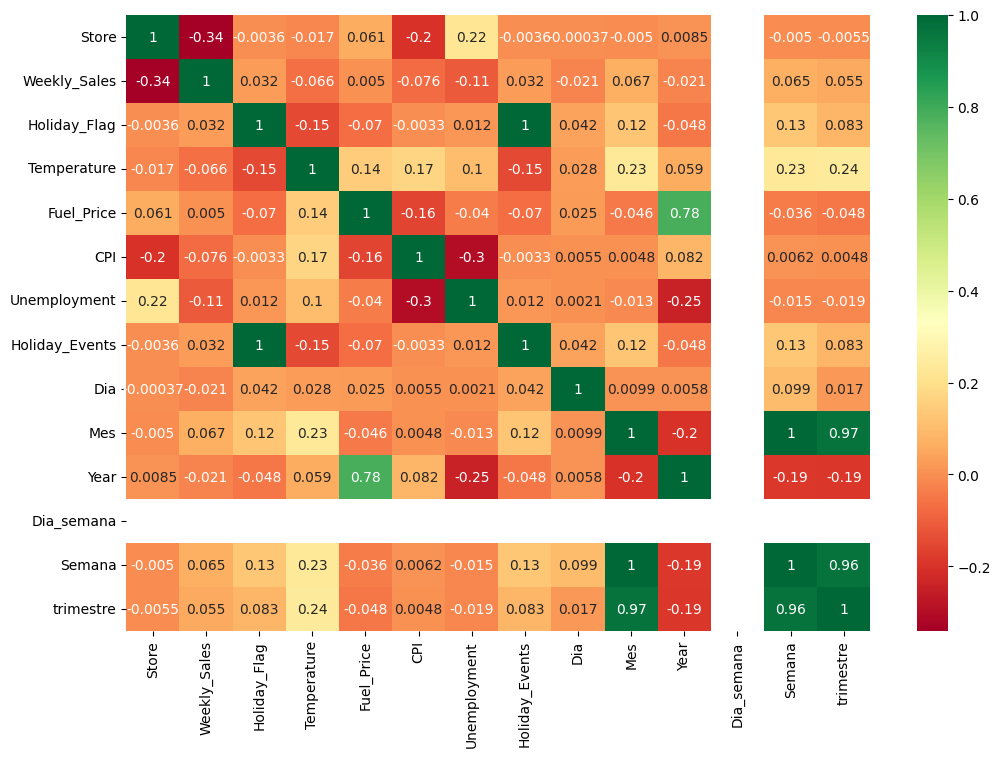

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(correl, annot=True,cmap='RdYlGn')

# Preprocesamiento

En esta etapa de preprocesamiento lo que aremos es lo siguiente:

- Scalar los datos: En vista de que los datos tienen diferentes escalar, vamos a escalar los datos usando MinMaxScaler. Este escalador le resta el valor mínimo a cada característica y divide entre la diferencia entre el valor mínimo y máximo.
- Separación en entrenamiento y test.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

target = df['Weekly_Sales'].to_numpy().reshape(-1,1) # pasamos de tener una lista a tener un array de [n,1]
X = df.drop(columns=['Weekly_Sales'], axis=1)

escalador = MinMaxScaler()
XScalado = escalador.fit_transform(X)               # no convertimos a dataframe ya que las redes neuranles usan array

X_train,X_test, Y_train, Y_test = train_test_split(XScalado,target,test_size=0.2, random_state=42,shuffle=True)

# Modelado

Ahora que ya tenemos nuestros datos escalados y son de tipo array, procedemos a definir la función de entrenamiento y evalución de la red neuronal.

In [14]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping



def entrenar_y_evaluar(modelo,patience = 50, max_epochs=200):
    # definamos la parada temprana
    earlystop = EarlyStopping(
        monitor ='val_r_squared', # monitorea la périda de validación, usar loss si no hay datos de validación
        patience=patience,
        restore_best_weights=True,
        mode = 'max' 
    )
    # Definición de R² (coeficiente de determinación)
    def r_squared(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)  # Asegura que ambos sean float32
        y_pred = tf.cast(y_pred, tf.float32)
        
        ss_res = K.sum(K.square(y_true - y_pred))
        ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
        
        r2 = 1.0 - ss_res / (ss_tot + K.epsilon())  # Evita división por cero
        return r2
    
    # compilar el modelo
    modelo.compile(
        loss = 'mean_squared_error', # Es la función de pérdida estandar para problemas de regresión.
        optimizer ='sgd',
        metrics =[r_squared]
    )

    # Entrenar el modelo
    history = modelo.fit(
        x = X_train,
        y = Y_train,
        validation_split = 0.05,
        epochs = max_epochs,
        callbacks = [earlystop]
    )
    return  history


2025-08-05 09:36:26.400717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754404586.450060    9510 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754404586.463783    9510 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754404586.566518    9510 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754404586.566538    9510 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754404586.566540    9510 computation_placer.cc:177] computation placer alr

In [ ]:
tf.keras.backend.clear_session() # reiniciar el kernel
modelo = Sequential([
    Dense(units=120,activation='relu'),
    Dropout(0.2),
    Dense(units=60,activation='relu'),
    Dense(1, activation='relu') # la salida debe ser positiva , por eso usamos relu
])

Ahora si, procedamos a entrenar el modelo.

In [ ]:
historial = entrenar_y_evaluar(modelo=modelo)
historial.history.keys()
historia_Epoca= pd.DataFrame(historial.history)

In [ ]:
scores = pd.DataFrame([modelo.evaluate(X_test, Y_test)],
                      columns =modelo.metrics_names)
scores.head()

evaluemos el modelo